# **Lab 05.1 - Continuous and Policy-Based RL with DDPG and PPO**

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This notebook covers:
- **MountainCarContinuous-v0** for **DDPG (From Scratch)** and **TD3 (Stable-Baselines3)**
- **CartPole-v1** for **PPO (From Scratch)** and **PPO (Stable-Baselines3)**

### Imports and Setup

The following cell configures the runtime and defines shared utilities used across all parts of this lab.

In [1]:
# Runtime stability settings for notebook environments on macOS
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Keep CPU thread usage predictable in notebook kernels
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

try:
    from stable_baselines3 import PPO as SB3PPO, TD3
    from stable_baselines3.common.noise import NormalActionNoise
    sb3_library_available = True
except Exception:
    SB3PPO = None
    TD3 = None
    NormalActionNoise = None
    sb3_library_available = False

# Reproducibility settings
SEED = 42
FAST_MODE = True

# Set seeds for all libraries to ensure reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.25})

print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

Device: cuda
PyTorch: 2.5.1
NumPy: 2.0.1
Gymnasium: 1.2.2
FAST_MODE: True


In [2]:
def moving_average_curve(raw_values, window_size=10):
    values_array = np.asarray(raw_values, dtype=np.float32)
    if len(values_array) < window_size:
        return values_array
    kernel_array = np.ones(window_size, dtype=np.float32) / window_size
    return np.convolve(values_array, kernel_array, mode='valid')


def plot_training_curve(training_values, title_text, y_label_text='Return', window_size=10):
    plt.figure(figsize=(8.5, 3.8))
    plt.plot(training_values, alpha=0.35, label='Raw')
    averaged_values = moving_average_curve(training_values, window_size=window_size)
    if len(averaged_values) > 0:
        x_index_values = np.arange(window_size - 1, window_size - 1 + len(averaged_values))
        plt.plot(x_index_values, averaged_values, linewidth=2.0, label=f'MA({window_size})')
    plt.title(title_text)
    plt.xlabel('Episode / Epoch')
    plt.ylabel(y_label_text)
    plt.legend()
    plt.show()


def evaluate_policy_returns(environment_name, policy_action_function, episode_count=8, seed_offset_value=1000):
    episodic_return_values = []
    for episode_index in range(episode_count):
        evaluation_env_instance = gym.make(environment_name)
        current_state, _ = evaluation_env_instance.reset(seed=SEED + seed_offset_value + episode_index)
        episode_done_flag = False
        total_episode_return = 0.0
        while not episode_done_flag:
            selected_action = policy_action_function(current_state)
            next_state, reward_value, terminated_flag, truncated_flag, _ = evaluation_env_instance.step(selected_action)
            total_episode_return += reward_value
            current_state = next_state
            episode_done_flag = terminated_flag or truncated_flag
        episodic_return_values.append(total_episode_return)
        evaluation_env_instance.close()
    return np.asarray(episodic_return_values, dtype=np.float32)

## Part 1: Continuous Control via Deep Deterministic Policy Gradient (DDPG)

### 1.1. Environment Exploration & Continuous Replay Buffer

**Pipeline Architecture**:
1. Initialize `mountaincar_continuous_env` and inspect state/action dimensions.
2. Collect transitions `(s_t, a_t, r_t, s_{t+1}, done_t)` while interacting with the environment.
3. Push each transition into `ContinuousReplayBuffer`.
4. Sample mini-batches for gradient updates in later cells.

**Component Interactions**:
- This environment cell defines action bounds used by actor output scaling.
- `ContinuousReplayBuffer` is consumed directly by the DDPG trainer update routine.

**Mathematical/Algorithmic Anchors**:
- Off-policy stochastic gradient estimation from sampled replay batches.
- Temporal-difference target construction in downstream DDPG updates.

In [3]:
# Probe the MountainCarContinuous-v0 environment to understand its observation and action spaces, as well as reward structure
mountaincar_continuous_env = 'MountainCarContinuous-v0'
mountaincar_probe_env = gym.make(mountaincar_continuous_env)
probe_observation, _ = mountaincar_probe_env.reset(seed=SEED)
sample_continuous_action = mountaincar_probe_env.action_space.sample()
_, probe_reward, probe_terminated, probe_truncated, _ = mountaincar_probe_env.step(sample_continuous_action)

print('Environment:', mountaincar_continuous_env)
print('Observation shape:', mountaincar_probe_env.observation_space.shape)
print('Action shape:', mountaincar_probe_env.action_space.shape)
print('Sample reward:', probe_reward)
print('Episode done from sample step:', probe_terminated or probe_truncated)

mountaincar_probe_env.close()

Environment: MountainCarContinuous-v0
Observation shape: (2,)
Action shape: (1,)
Sample reward: -0.01307330162277589
Episode done from sample step: False


In [4]:
# Define a replay buffer class for storing and sampling transitions during training 
class ContinuousReplayBuffer:
    def __init__(self, buffer_capacity=100000):
        self.transition_buffer = deque(maxlen=buffer_capacity)

    def push(self, state, action, reward, next_state, done):
        # Store a transition tuple in the replay buffer
        self.transition_buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size=64):
        # Randomly sample a batch of transitions from the replay buffer and convert them to PyTorch tensors
        sampled_indices = np.random.choice(len(self.transition_buffer), batch_size, replace=False)
        # Retrieve the sampled transitions and unzip them into separate arrays for states, actions, rewards, next states, and done flags
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        sampled_batch = [np.array(self.transition_buffer[idx]) for idx in sampled_indices]
        states_array, actions_array, rewards_array, next_states_array, dones_array = zip(*sampled_batch)
        
        return (
            torch.tensor(states_array, dtype=torch.float32, device=device),
            torch.tensor(actions_array, dtype=torch.float32, device=device),
            torch.tensor(rewards_array, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(next_states_array, dtype=torch.float32, device=device),
            torch.tensor(dones_array, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.transition_buffer)

### 1.2. DDPG Network Architectures (From Scratch)

**Pipeline Architecture**:
1. Define two neural architectures only: `DDPGActor` and `DDPGCritic`.
2. Instantiate four network objects: `ddpg_online_actor`, `ddpg_target_actor`, `ddpg_online_critic`, `ddpg_target_critic`.
3. Copy online parameters to target parameters before training.
4. Use online networks for gradient updates and target networks for stable TD targets.

**Component Interactions**:
- `ddpg_online_actor` proposes actions for current states.
- `ddpg_online_critic` evaluates `(state, action)` pairs and receives gradients from Bellman errors.
- `ddpg_target_actor` and `ddpg_target_critic` are queried only for TD target computation.

**Mathematical/Algorithmic Anchors**:
- Stable target equation: $y_i = r_i + \gamma Q_{target}(s_{i+1}, \mu_{target}(s_{i+1}))$.
- Deterministic policy gradient updates actor via $\nabla_a Q(s,a) |_{a=\mu(s)}$.

**Why 2 definitions but 4 instances?**
- The architecture classes define *parameterized functions* only once.
- Two online instances are trainable and move every update step.
- Two target instances change slowly with soft updates to avoid moving-target divergence during TD learning.

In [5]:
class DDPGActor(nn.Module):
    def __init__(self, state_dimension, action_dimension, max_action_magnitude, hidden_size=256):
        super().__init__()
        # max_action_magnitude is used to scale the output of the actor network to ensure it falls within the valid action range of the environment. 
        self.max_action_magnitude = max_action_magnitude
        self.actor_network = nn.Sequential(
            # Architechture of the actor network:
            # Linear (state_dimension -> hidden_size) -> ReLU -> Linear (hidden_size -> hidden_size) -> ReLU -> Linear (hidden_size -> action_dimension) -> Tanh
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(state_dimension, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dimension),
            nn.Tanh(),
        )
        # The final layer uses Tanh activation, which outputs values in the range [-1, 1]. 

    def forward(self, state_tensor):
        # By multiplying with max_action_magnitude, we can scale this output to match the action space of the environment.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        return self.max_action_magnitude * self.actor_network(state_tensor)


class DDPGCritic(nn.Module):
    def __init__(self, state_dimension, action_dimension, hidden_size=256):
        super().__init__()
        self.critic_network = nn.Sequential(
            # The critic network takes both the state and action as input, 
            # so we concatenate them along the feature dimension (dim=1) before passing through the network.
            # Architechture of the critic network:
            # Linear (state_dimension + action_dimension -> hidden_size) -> ReLU -> Linear (hidden_size -> hidden_size) -> ReLU -> Linear (hidden_size -> 1)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(state_dimension + action_dimension, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, state_tensor, action_tensor):
        # Concatenate the state and action tensors along the feature dimension (dim=1) 
        # before passing through the critic network to get the Q-value estimate for that state-action pair.
        concatenated = torch.cat([state_tensor, action_tensor], dim=1)
        return self.critic_network(concatenated)


env = gym.make(mountaincar_continuous_env)
# Extract the dimensions of the state and action spaces, 
ddpg_state_dimension = env.observation_space.shape[0]
ddpg_action_dimension = env.action_space.shape[0]
# The maximum action value is determined by the environment's action space, 
# which is typically symmetric around zero for continuous control tasks.
ddpg_max_action_value = float(env.action_space.high[0])
env.close()

# Initialize the online and target networks for both the actor and critic
### YOU NEED TO WRITE YOUR CODE BELOW ###
ddpg_online_actor = DDPGActor(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension, max_action_magnitude=ddpg_max_action_value).to(device)
ddpg_target_actor = DDPGActor(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension, max_action_magnitude=ddpg_max_action_value).to(device)
ddpg_online_critic = DDPGCritic(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension).to(device)
ddpg_target_critic = DDPGCritic(state_dimension=ddpg_state_dimension, action_dimension=ddpg_action_dimension).to(device)

# Copy the weights from the online networks to the target networks
### YOU NEED TO WRITE YOUR CODE BELOW ###
ddpg_target_actor.load_state_dict(ddpg_online_actor.state_dict())
ddpg_target_critic.load_state_dict(ddpg_online_critic.state_dict())

ddpg_actor_optimizer = optim.Adam(ddpg_online_actor.parameters(), lr=1e-4)
ddpg_critic_optimizer = optim.Adam(ddpg_online_critic.parameters(), lr=1e-3)
ddpg_replay_buffer = ContinuousReplayBuffer(buffer_capacity=120000)

print('DDPG actor and critic instances initialized successfully.')

DDPG actor and critic instances initialized successfully.


### 1.3. Exploration Noise & Training Loop

**Pipeline Architecture**:
1. Actor emits deterministic continuous action.
2. Add Gaussian exploration noise during training.
3. Store transition in replay buffer.
4. Sample batch and compute critic target using target actor/critic.
5. Update online critic then online actor.
6. Soft-update target parameters with $\theta' \leftarrow \tau\theta + (1-\tau)\theta'$.

**Component Interactions**:
- Training environment drives data collection.
- Replay buffer decouples data collection from optimization.
- Optimizers update online networks; target networks track online networks smoothly.

**Mathematical/Algorithmic Anchors**:
- Critic MSE loss between $Q_{online}(s_t, a_t)$ and TD target $y_t$.
- Actor objective maximizes critic estimate $Q(s, \mu(s))$ via minimizing negative mean Q.

[DDPG] Episode 6/24 Return=-4.27
[DDPG] Episode 12/24 Return=-4.11
[DDPG] Episode 18/24 Return=-3.93
[DDPG] Episode 24/24 Return=-3.95


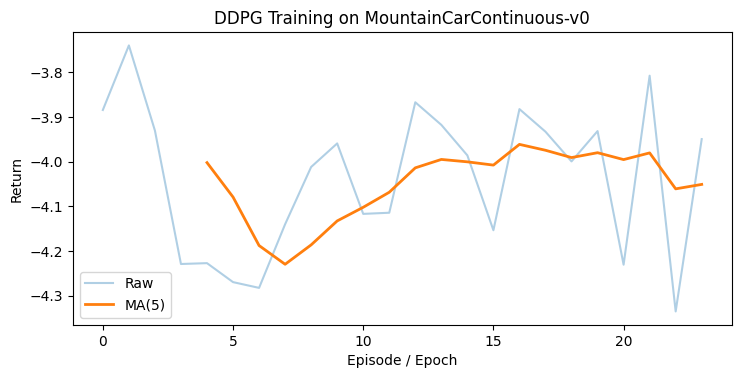

In [6]:
class GaussianExplorationNoise:
    def __init__(self, action_dimension, sigma_value=0.2):
        self.action_dimension = action_dimension
        self.sigma_value = sigma_value

    def sample(self):

        # Generate Gaussian noise with mean 0 and standard deviation sigma_value for each action dimension
        # using NumPy's random.normal function
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        return np.random.normal(0, self.sigma_value, size=self.action_dimension)


class DDPGTrainer:
    def __init__(self):
        self.discount_gamma = 0.99
        self.soft_update_tau = 0.005
        self.batch_size = 64
        self.exploration_noise = GaussianExplorationNoise(ddpg_action_dimension, sigma_value=0.15)

    def select_action(self, state_vector, training_mode=True):
        state_tensor = torch.tensor(state_vector, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            # deterministic_action = output of the online actor network for the given state
            # cpu() is used to move the tensor to CPU memory, and numpy() converts it to a NumPy array.
            deterministic_action = ddpg_online_actor(state_tensor).cpu().numpy().flatten()
        if training_mode:
            # Add exploration noise to the deterministic action output by the actor network 
            # during training to encourage exploration of the action space.
            deterministic_action = deterministic_action + self.exploration_noise.sample()
        # The resulting action is then clipped to ensure it falls within the valid action range 
        # defined by the environment's action space.
        clipped_action = np.clip(deterministic_action, -ddpg_max_action_value, ddpg_max_action_value)
        return clipped_action

    def soft_update_target_network(self, online_network, target_network):
        # Perform a soft update of the target network's parameters towards the online network's parameters using the formula:
        for online_parameter, target_parameter in zip(online_network.parameters(), target_network.parameters()):
            target_parameter.data.copy_(
                # fomula: target_parameter = tau * online_parameter + (1 - tau) * target_parameter
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                self.soft_update_tau * online_parameter.data + (1.0 - self.soft_update_tau) * target_parameter.data
            )

    def train_step(self):
        if len(ddpg_replay_buffer) < self.batch_size:
            return
        sampled_states, sampled_actions, sampled_rewards, sampled_next_states, sampled_dones = ddpg_replay_buffer.sample(self.batch_size)

        with torch.no_grad():
            # target_actions = output of the target actor network for the sampled next states
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            target_actions = ddpg_target_actor(torch.tensor(sampled_next_states, dtype=torch.float32, device=device))   
            # target_q_values = output of the target critic network for the sampled next states and the target actions
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            target_q_values = ddpg_target_critic(torch.tensor(sampled_next_states, dtype=torch.float32, device=device), target_actions)
            td_target_values = sampled_rewards + self.discount_gamma * (1.0 - sampled_dones) * target_q_values
        
        # current_q_values = output of the online critic network for the sampled states and sampled actions
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        current_q_values = ddpg_online_critic(torch.tensor(sampled_states, dtype=torch.float32, device=device), torch.tensor(sampled_actions, dtype=torch.float32, device=device))
        critic_loss_value = nn.MSELoss()(current_q_values, td_target_values)
        ddpg_critic_optimizer.zero_grad()
        critic_loss_value.backward()
        ddpg_critic_optimizer.step()
        
        # actor_loss_value = negative mean of the output of the online critic network for the sampled states 
        # and the actions output by the online actor network for those sampled states
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        actor_loss_value =  -ddpg_online_critic(torch.tensor(sampled_states, dtype=torch.float32, device=device), ddpg_online_actor(torch.tensor(sampled_states, dtype=torch.float32, device=device))).mean()
        ddpg_actor_optimizer.zero_grad()
        actor_loss_value.backward()
        ddpg_actor_optimizer.step()

        self.soft_update_target_network(ddpg_online_actor, ddpg_target_actor)
        self.soft_update_target_network(ddpg_online_critic, ddpg_target_critic)


ddpg_trainer = DDPGTrainer()
ddpg_training_environment = gym.make(mountaincar_continuous_env)
ddpg_episode_count = 24 if FAST_MODE else 120
ddpg_training_returns = []

for ddpg_episode_index in range(ddpg_episode_count):
    episode_state, _ = ddpg_training_environment.reset(seed=SEED + ddpg_episode_index)
    episode_done = False
    episode_return_value = 0.0
    while not episode_done:
        selected_action = ddpg_trainer.select_action(episode_state, training_mode=True)
        next_state, reward_value, terminated_flag, truncated_flag, _ = ddpg_training_environment.step(selected_action)
        transition_done = float(terminated_flag or truncated_flag)
        ddpg_replay_buffer.push(episode_state, selected_action, reward_value, next_state, transition_done)

        # Perform a training step for the DDPG agent, which involves sampling a batch of transitions from the replay buffer,
        # computing the critic and actor losses, and updating the online networks accordingly.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###

        
        episode_state = next_state
        episode_return_value += reward_value
        episode_done = terminated_flag or truncated_flag
    ddpg_training_returns.append(episode_return_value)
    if (ddpg_episode_index + 1) % 6 == 0:
        print(f'[DDPG] Episode {ddpg_episode_index + 1}/{ddpg_episode_count} Return={episode_return_value:.2f}')

ddpg_training_environment.close()
plot_training_curve(ddpg_training_returns, 'DDPG Training on MountainCarContinuous-v0', window_size=5)

## Part 2: Advanced Continuous Control via Twin Delayed DDPG (TD3)

### 2.1. TD3 Implementation via Stable-Baselines3

**Pipeline Architecture**:
1. Initialize `td3_training_environment` using `mountaincar_continuous_env`.
2. Configure TD3 with action noise and twin-critic internals (provided by SB3).
3. Learn policy parameters over a fixed timesteps budget.

**Component Interactions**:
- SB3 TD3 baseline reuses the same environment setting as DDPG for fair comparison.
- Evaluator cell directly compares DDPG and TD3 under consistent seeds.

**Mathematical/Algorithmic Anchors**:
- Twin-critic min target in TD3 addresses Q overestimation.
- Delayed policy updates reduce actor overfitting to critic noise.

In [7]:
if sb3_library_available:
    td3_training_environment = gym.make(mountaincar_continuous_env)
    td3_action_dimension = td3_training_environment.action_space.shape[0]
    td3_action_noise = NormalActionNoise(mean=np.zeros(td3_action_dimension), sigma=0.1 * np.ones(td3_action_dimension))

    td3_sb3_model = TD3(
        'MlpPolicy',
        td3_training_environment,
        learning_rate=1e-3,
        buffer_size=50000,
        batch_size=128,
        gamma=0.99,
        tau=0.005,
        policy_delay=2,
        action_noise=td3_action_noise,
        seed=SEED,
        verbose=0,
        device=device,
    )
    td3_training_timesteps = 6000 if FAST_MODE else 32000
    td3_sb3_model.learn(total_timesteps=td3_training_timesteps, progress_bar=False)
    td3_training_environment.close()
else:
    td3_sb3_model = None
    print('SB3 not available: TD3 baseline skipped.')

### 2.2. Performance Evaluation & Visualization

**Pipeline Architecture**:
1. Evaluate trained DDPG deterministic policy.
2. Evaluate SB3 TD3 deterministic policy when available.
3. Aggregate means and standard deviations.
4. Produce comparison tables and bar plots (Lab 4 style).

**Component Interactions**:
- Uses shared `evaluate_policy_returns` helper and common seeds.
- Outputs feed into `pandas` table and Matplotlib visualization.

**Mathematical/Algorithmic Anchors**:
- Episodic return expectation approximated by Monte Carlo averaging across seeded episodes.

                mean_return  std_return
DDPG (Scratch)    -1.793139    0.011149
TD3 (SB3)         -0.000244    0.000014


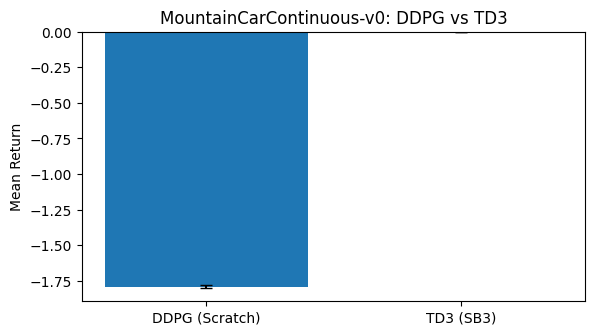

In [8]:
def ddpg_deterministic_action_function(observation_state):
    state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        deterministic_action = ddpg_online_actor(state_tensor).cpu().numpy()[0]
    return np.clip(deterministic_action, -ddpg_max_action_value, ddpg_max_action_value)


continuous_results_dictionary = {}
ddpg_evaluation_returns = evaluate_policy_returns(
    mountaincar_continuous_env, ddpg_deterministic_action_function, episode_count=10, seed_offset_value=2000
)
continuous_results_dictionary['DDPG (Scratch)'] = {
    'mean_return': float(ddpg_evaluation_returns.mean()),
    'std_return': float(ddpg_evaluation_returns.std()),
}

if td3_sb3_model is not None:
    def td3_deterministic_action_function(observation_state):
        td3_action_value, _ = td3_sb3_model.predict(observation_state, deterministic=True)
        return td3_action_value

    td3_evaluation_returns = evaluate_policy_returns(
        mountaincar_continuous_env, td3_deterministic_action_function, episode_count=10, seed_offset_value=3000
    )
    continuous_results_dictionary['TD3 (SB3)'] = {
        'mean_return': float(td3_evaluation_returns.mean()),
        'std_return': float(td3_evaluation_returns.std()),
    }

continuous_results_frame = pd.DataFrame(continuous_results_dictionary).T
print(continuous_results_frame)

plt.figure(figsize=(6.5, 3.5))
plt.bar(
    continuous_results_frame.index,
    continuous_results_frame['mean_return'],
    yerr=continuous_results_frame['std_return'],
    capsize=4,
)
plt.title('MountainCarContinuous-v0: DDPG vs TD3')
plt.ylabel('Mean Return')
plt.show()

## Part 3: Discrete Control via Proximal Policy Optimization (PPO)

### 3.1. PPO Policy & Value Networks (From Scratch)

**Pipeline Architecture**:
1. Initialize `cartpole_discrete_env` and inspect state/action dimensions.
2. `ppo_scratch_policy_net` emits logits over discrete actions.
3. Sample action using `torch.distributions.Categorical`.
4. Store `(state, action, log_prob, reward, done, value)` in `DiscreteRolloutBuffer`.

**Component Interactions**:
- Policy and value networks are optimized jointly in PPO updates.
- Rollout buffer supplies trajectories to GAE and clipped objective cells.

**Mathematical/Algorithmic Anchors**:
- Categorical policy: $\pi_\theta(a|s)=\text{Softmax}(\text{logits}_\theta(s))$.
- Log-probabilities from Categorical distribution support PPO ratio computation.

In [9]:
# Probe the CartPole-v1 environment to understand its observation and action spaces, as well as reward structure
cartpole_discrete_env = 'CartPole-v1'
cartpole_probe_env = gym.make(cartpole_discrete_env)
cartpole_observation_dimension = cartpole_probe_env.observation_space.shape[0]
cartpole_action_count = cartpole_probe_env.action_space.n

print('Environment:', cartpole_discrete_env)
print('Observation dimension:', cartpole_observation_dimension)
print('Action count:', cartpole_action_count)

cartpole_probe_env.close()

Environment: CartPole-v1
Observation dimension: 4
Action count: 2


In [10]:
class DiscreteRolloutBuffer:
    def __init__(self):
        self.clear()

    def clear(self):
        self.state_list = []
        self.action_list = []
        self.log_probability_list = []
        self.reward_list = []
        self.done_list = []
        self.value_list = []

    def add(self, state_value, action_value, log_probability_value, reward_value, done_value, value_estimate):
        self.state_list.append(state_value)
        self.action_list.append(int(action_value))
        self.log_probability_list.append(float(log_probability_value))
        self.reward_list.append(float(reward_value))
        self.done_list.append(float(done_value))
        self.value_list.append(float(value_estimate))


class PPOScratchNetwork(nn.Module):
    def __init__(self, state_dimension, action_count, hidden_size=128):
        super().__init__()
        self.shared_torso = nn.Sequential(

            
            # Architechture of the shared torso:
            # Linear (state_dimension -> hidden_size) -> Tanh -> Linear (hidden_size -> hidden_size) -> Tanh
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(state_dimension, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        # The policy head outputs action logits for each discrete action, 
        # while the value head outputs a single scalar value estimate for the input state.
        # ppo_scratch_policy_net = Linear layer that maps the shared latent representation to action logits for each discrete action
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.ppo_scratch_policy_net = nn.Linear(hidden_size, action_count)
        # ppo_scratch_value_net = Linear layer that maps the shared latent representation to a single scalar value estimate for the input state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.ppo_scratch_value_net = nn.Linear(hidden_size, 1)

    def forward(self, state_tensor):
        # latent_tensor = output of the shared torso network for the given input state tensor
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        latent_tensor = self.shared_torso(state_tensor)
        # action_logits = output of the policy head network for the latent representation, 
        # which gives the unnormalized log probabilities for each discrete action
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action_logits = self.ppo_scratch_policy_net(latent_tensor)
        # state_value = output of the value head network for the latent representation, 
        # which gives the estimated value of the input state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_value = self.ppo_scratch_value_net(latent_tensor)
        return action_logits, state_value

### 3.2. Generalized Advantage Estimation (GAE) & Optimization Loop

**Pipeline Architecture**:
1. Collect on-policy rollout with current PPO parameters.
2. Compute GAE advantages and returns.
3. Re-evaluate policy logits and values on mini-batches.
4. Compute PPO clipped policy loss + value loss + entropy regularization.
5. Update parameters over multiple epochs.

**Component Interactions**:
- `DiscreteRolloutBuffer` feeds this optimization loop.
- `PPOScratchNetwork` outputs both policy logits and value estimates.

**Mathematical/Algorithmic Anchors**:
- GAE recursion for variance-reduced advantages.
- Clipped surrogate: $L^{clip}(\theta) = \mathbb{E}[\min(r_t(\theta)A_t, \text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t)]$.

In [11]:
def compute_generalized_advantages(reward_sequence, done_sequence, value_sequence, gamma_value=0.99, lambda_value=0.95):
    advantage_values = []
    running_gae = 0.0
    extended_values = list(value_sequence) + [0.0]
    for transition_index in reversed(range(len(reward_sequence))):
        # td_error = reward + gamma * next_value * (1 - done) - current_value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        td_error = reward_sequence[transition_index] + gamma_value * extended_values[transition_index + 1]* (1.0 - done_sequence[transition_index]) - extended_values[transition_index]
        # GAE = td_error + gamma * lambda * (1 - done) * running_gae
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        running_gae = td_error + gamma_value * lambda_value * (1.0 - done_sequence[transition_index]) * running_gae
        advantage_values.insert(0, running_gae)
    advantage_array = np.asarray(advantage_values, dtype=np.float32)
    
    # return = advantage + value, which gives the target return for each state, 
    # used for training the value function in PPO.
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    return_array = advantage_array + np.asarray(value_sequence, dtype=np.float32)
    return advantage_array, return_array


class PPOScratchTrainer:
    def __init__(self, state_dimension, action_count, learning_rate=3e-4, clip_ratio=0.2):
        self.clip_ratio = clip_ratio
        self.policy_value_network = PPOScratchNetwork(state_dimension, action_count).to(device)
        self.network_optimizer = optim.Adam(self.policy_value_network.parameters(), lr=learning_rate)

    def sample_action(self, observation_state):
        state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            # action_logits, state_value = output of the policy-value network for the given state tensor, 
            # which includes the action logits for each discrete action and the estimated state value.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            action_logits, state_value = self.policy_value_network(state_tensor)
            categorical_distribution = torch.distributions.Categorical(logits=action_logits)
            sampled_action_tensor = categorical_distribution.sample()
            sampled_log_probability = categorical_distribution.log_prob(sampled_action_tensor)
        return int(sampled_action_tensor.item()), float(sampled_log_probability.item()), float(state_value.item())

    def greedy_action(self, observation_state):
        state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action_logits, _ = self.policy_value_network(state_tensor)
        greedy_action = int(torch.argmax(action_logits, dim=1).item())
        return greedy_action

    def optimize_from_buffer(self, rollout_buffer, gamma_value=0.99, lambda_value=0.95, epochs_count=4, minibatch_size=128):
        # Convert the collected rollout data into PyTorch tensors for efficient batch processing during optimization.
        # state_tensor = tensor containing the states from the rollout buffer, converted to float32 and moved to the appropriate device (CPU or GPU).
        # action_tensor = tensor containing the actions from the rollout buffer, converted to long integers (for indexing) and moved to the appropriate device.
        # old_log_probability_tensor = tensor containing the log probabilities of the actions taken during the rollout, converted to float32 and moved to the appropriate device.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_tensor = torch.tensor(np.asarray(rollout_buffer.state_list), dtype=torch.float32, device=device)
        action_tensor = torch.tensor(rollout_buffer.action_list, dtype=torch.long, device=device)
        old_log_probability_tensor = torch.tensor(rollout_buffer.log_probability_list, dtype=torch.float32, device=device)

        advantage_array, return_array = compute_generalized_advantages(
            rollout_buffer.reward_list,
            rollout_buffer.done_list,
            rollout_buffer.value_list,
            gamma_value=gamma_value,
            lambda_value=lambda_value,
        )
        
        advantage_tensor = torch.tensor(advantage_array, dtype=torch.float32, device=device)
        return_tensor = torch.tensor(return_array, dtype=torch.float32, device=device).unsqueeze(1)
        # Normalize the advantage estimates to have zero mean and unit variance, 
        # which can help stabilize training by preventing excessively large updates to the policy parameters.
        advantage_tensor = (advantage_tensor - advantage_tensor.mean()) / (advantage_tensor.std() + 1e-8)

        sample_count = state_tensor.shape[0]
        index_array = np.arange(sample_count)

        for _ in range(epochs_count):
            # Shuffle the indices of the collected samples to ensure that each optimization epoch processes the data in a different order, 
            # which can help improve generalization and prevent overfitting to specific sequences of transitions.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            np.random.shuffle(index_array)

            for start_index in range(0, sample_count, minibatch_size):
                
                ### batch_indices = subset of shuffled indices for the current mini-batch
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                batch_indices = index_array[start_index:start_index + minibatch_size]

                batch_states = state_tensor[batch_indices]
                batch_actions = action_tensor[batch_indices]
                batch_old_log_probabilities = old_log_probability_tensor[batch_indices]
                batch_advantages = advantage_tensor[batch_indices]
                batch_returns = return_tensor[batch_indices]

                batch_logits, batch_values = self.policy_value_network(batch_states)
                batch_distribution = torch.distributions.Categorical(logits=batch_logits)
                batch_new_log_probabilities = batch_distribution.log_prob(batch_actions)

                # probability_ratio = exp(new_log_probability - old_log_probability) = new_probability / old_probability
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                probability_ratio = torch.exp(batch_new_log_probabilities - batch_old_log_probabilities)

                # unclipped_objective = probability_ratio * batch_advantages
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                unclipped_objective = probability_ratio * batch_advantages
                
                # clipped_objective = clamp the probability_ratio to be within [1 - clip_ratio, 1 + clip_ratio] and then multiply by batch_advantages
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                clipped_objective = torch.clamp(probability_ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio) * batch_advantages
                # - sign is used because we typically minimize the loss, 
                # but the PPO objective is formulated as a maximization problem,
                clipped_policy_loss = -torch.min(unclipped_objective, clipped_objective).mean()

                # The value loss is computed as the mean squared error between the predicted state values and the computed returns,
                value_loss = nn.MSELoss()(batch_values, batch_returns)  
                entropy_bonus = batch_distribution.entropy().mean()
                total_loss = clipped_policy_loss + 0.5 * value_loss - 0.01 * entropy_bonus

                self.network_optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(self.policy_value_network.parameters(), 0.5)
                self.network_optimizer.step()

[PPO Scratch] Epoch 6/192 Return=512.00
[PPO Scratch] Epoch 12/192 Return=512.00
[PPO Scratch] Epoch 18/192 Return=512.00
[PPO Scratch] Epoch 24/192 Return=512.00
[PPO Scratch] Epoch 30/192 Return=512.00
[PPO Scratch] Epoch 36/192 Return=512.00
[PPO Scratch] Epoch 42/192 Return=512.00
[PPO Scratch] Epoch 48/192 Return=512.00
[PPO Scratch] Epoch 54/192 Return=512.00
[PPO Scratch] Epoch 60/192 Return=512.00
[PPO Scratch] Epoch 66/192 Return=512.00
[PPO Scratch] Epoch 72/192 Return=512.00
[PPO Scratch] Epoch 78/192 Return=512.00
[PPO Scratch] Epoch 84/192 Return=512.00
[PPO Scratch] Epoch 90/192 Return=512.00
[PPO Scratch] Epoch 96/192 Return=512.00
[PPO Scratch] Epoch 102/192 Return=512.00
[PPO Scratch] Epoch 108/192 Return=512.00
[PPO Scratch] Epoch 114/192 Return=512.00
[PPO Scratch] Epoch 120/192 Return=512.00
[PPO Scratch] Epoch 126/192 Return=512.00
[PPO Scratch] Epoch 132/192 Return=512.00
[PPO Scratch] Epoch 138/192 Return=512.00
[PPO Scratch] Epoch 144/192 Return=512.00
[PPO Scra

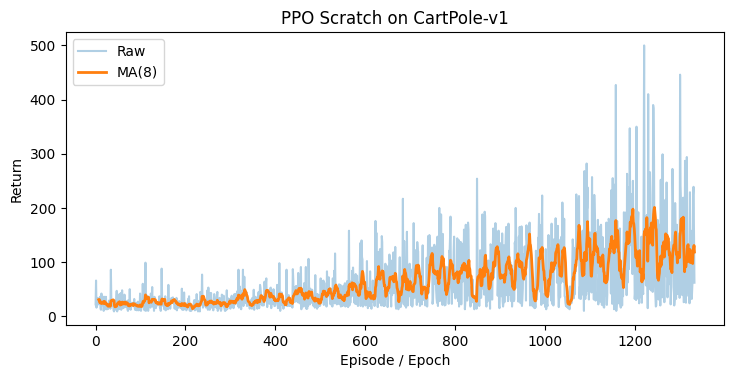

PPO Scratch mean/std: 330.9166564941406 16.04918670654297


In [19]:
ppo_scratch_trainer = PPOScratchTrainer(cartpole_observation_dimension, cartpole_action_count, learning_rate=3e-4, clip_ratio=0.2)
cartpole_rollout_buffer = DiscreteRolloutBuffer()
cartpole_training_environment = gym.make(cartpole_discrete_env)

ppo_training_epochs = 192 if FAST_MODE else 120
rollout_steps_per_epoch = 512
ppo_training_returns = []
ppo_episode_returns = []

for epoch_index in range(ppo_training_epochs):
    cartpole_rollout_buffer.clear()
    current_observation, _ = cartpole_training_environment.reset(seed=SEED + epoch_index)
    epoch_return_value = 0.0
    current_episode_return = 0.0

    for _ in range(rollout_steps_per_epoch):
        selected_action, action_log_probability, value_estimate = ppo_scratch_trainer.sample_action(current_observation)
        next_observation, reward_value, terminated_flag, truncated_flag, _ = cartpole_training_environment.step(selected_action)
        done_value = float(terminated_flag or truncated_flag)
        # Store the transition data in the rollout buffer for later optimization after collecting a batch of transitions.
        cartpole_rollout_buffer.add(current_observation, selected_action, action_log_probability, reward_value, done_value, value_estimate)
        epoch_return_value += reward_value
        current_episode_return += reward_value
        current_observation = next_observation

        if terminated_flag or truncated_flag:
            ppo_episode_returns.append(current_episode_return)
            current_episode_return = 0.0
            current_observation, _ = cartpole_training_environment.reset()

    # After collecting the specified number of rollout steps for the current epoch, 
    # we call the optimize_from_buffer method of the PPO trainer to perform multiple epochs of optimization using mini-batches of the collected data, 
    # which updates the policy and value networks based on the PPO objective.
    ppo_scratch_trainer.optimize_from_buffer(
        cartpole_rollout_buffer, gamma_value=0.99, lambda_value=0.95, epochs_count=4, minibatch_size=128
    )
    ppo_training_returns.append(epoch_return_value)

    if (epoch_index + 1) % 6 == 0:
        print(f'[PPO Scratch] Epoch {epoch_index + 1}/{ppo_training_epochs} Return={epoch_return_value:.2f}')

cartpole_training_environment.close()
plot_training_curve(ppo_episode_returns, 'PPO Scratch on CartPole-v1', window_size=8)


def ppo_scratch_action_function(observation_state):
    return ppo_scratch_trainer.greedy_action(observation_state)

ppo_scratch_evaluation_returns = evaluate_policy_returns(
    cartpole_discrete_env, ppo_scratch_action_function, episode_count=12, seed_offset_value=4000
)
print('PPO Scratch mean/std:', float(ppo_scratch_evaluation_returns.mean()), float(ppo_scratch_evaluation_returns.std()))

## Part 4: Discrete Control via Stable-Baselines3 PPO

### 4.1. SB3 PPO Baseline Training

**Pipeline Architecture**:
1. Initialize SB3 PPO with MLP policy on `cartpole_discrete_env`.
2. Train baseline policy with standard PPO defaults adapted to this course lab.

**Component Interactions**:
- Baseline shares environment and evaluation harness with scratch PPO.

**Mathematical/Algorithmic Anchors**:
- PPO clipping, value updates, and entropy regularization are encapsulated in SB3 internals.

In [24]:
if sb3_library_available:
    ppo_sb3_training_environment = gym.make(cartpole_discrete_env)
    ppo_sb3_model = SB3PPO(
        'MlpPolicy',
        ppo_sb3_training_environment,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        seed=SEED,
        verbose=0,
        device=device,
    )
    ppo_sb3_training_timesteps = 18000 if FAST_MODE else 45000
    ppo_sb3_model.learn(total_timesteps=ppo_sb3_training_timesteps, progress_bar=False)
    ppo_sb3_training_environment.close()
else:
    ppo_sb3_model = None
    print('SB3 not available: PPO baseline skipped.')

c:\Users\Admin\anaconda3\envs\nt549-5-Tho\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


### 4.2. Comparative Evaluation

**Pipeline Architecture**:
1. Evaluate scratch PPO and SB3 PPO over shared seeded episodes.
2. Build a side-by-side result table.
3. Overlay mean-return bars with standard-deviation error bars.

**Component Interactions**:
- Evaluation helper function ensures reproducible comparison.

**Mathematical/Algorithmic Anchors**:
- Mean and variance estimates summarize policy reliability under stochastic trajectories.

             mean_return  std_return
PPO Scratch   330.916656   16.049187
PPO SB3       476.416656   55.667850


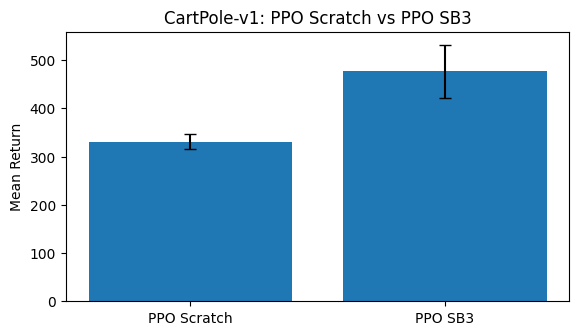

In [25]:
discrete_results_dictionary = {
    'PPO Scratch': {
        'mean_return': float(ppo_scratch_evaluation_returns.mean()),
        'std_return': float(ppo_scratch_evaluation_returns.std()),
    }
}

if ppo_sb3_model is not None:
    def ppo_sb3_action_function(observation_state):
        baseline_action, _ = ppo_sb3_model.predict(observation_state, deterministic=True)
        return int(baseline_action)

    ppo_sb3_evaluation_returns = evaluate_policy_returns(
        cartpole_discrete_env, ppo_sb3_action_function, episode_count=12, seed_offset_value=5000
    )
    discrete_results_dictionary['PPO SB3'] = {
        'mean_return': float(ppo_sb3_evaluation_returns.mean()),
        'std_return': float(ppo_sb3_evaluation_returns.std()),
    }

discrete_results_frame = pd.DataFrame(discrete_results_dictionary).T
print(discrete_results_frame)

plt.figure(figsize=(6.5, 3.5))
plt.bar(
    discrete_results_frame.index,
    discrete_results_frame['mean_return'],
    yerr=discrete_results_frame['std_return'],
    capsize=4,
)
plt.title('CartPole-v1: PPO Scratch vs PPO SB3')
plt.ylabel('Mean Return')
plt.show()

 clip_ratio  gae_lambda  train_last_return  eval_mean_return  eval_std_return  eval_max_return   scenario
       0.05        0.95              256.0            54.400           18.449             99.0 clip_ratio
       0.20        0.95              256.0            26.833            4.769             39.0 clip_ratio
       0.50        0.95              256.0            22.433            3.008             27.0 clip_ratio
       0.20        0.50              256.0            12.133            1.857             16.0 gae_lambda
       0.20        0.95              256.0            13.433            1.585             16.0 gae_lambda
       0.20        0.99              256.0           163.733          108.617            500.0 gae_lambda


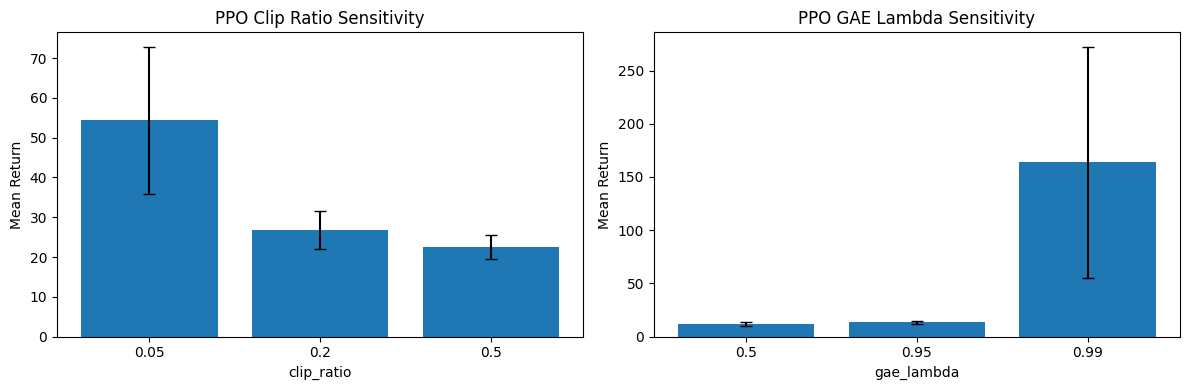

In [27]:
def run_cartpole_ppo_experiment(clip_ratio_value=0.2, gae_lambda_value=0.95, experiment_seed=SEED):
    random.seed(experiment_seed)
    np.random.seed(experiment_seed)
    torch.manual_seed(experiment_seed)
    trainer = PPOScratchTrainer(cartpole_observation_dimension, cartpole_action_count, learning_rate=3e-4, clip_ratio=clip_ratio_value)
    rollout_buffer = DiscreteRolloutBuffer()
    training_env = gym.make(cartpole_discrete_env)
    training_epochs = 8 if FAST_MODE else 40
    rollout_steps = 256 if FAST_MODE else 512
    training_returns = []

    for epoch_index in range(training_epochs):
        rollout_buffer.clear()
        observation, _ = training_env.reset(seed=experiment_seed + epoch_index)
        epoch_return = 0.0

        for step_index in range(rollout_steps):
            action, log_probability, value_estimate = trainer.sample_action(observation)
            next_observation, reward, terminated, truncated, _ = training_env.step(action)
            done = float(terminated or truncated)
            rollout_buffer.add(observation, action, log_probability, reward, done, value_estimate)
            epoch_return += reward
            observation = next_observation
            if terminated or truncated:
                observation, _ = training_env.reset(seed=experiment_seed + epoch_index + step_index + 10000)

        trainer.optimize_from_buffer(
            rollout_buffer,
            gamma_value=0.99,
            lambda_value=gae_lambda_value,
            epochs_count=3,
            minibatch_size=128,
        )
        training_returns.append(epoch_return)

    training_env.close()

    def action_function(observation_state):
        return trainer.greedy_action(observation_state)

    evaluation_returns = evaluate_policy_returns(
        cartpole_discrete_env,
        action_function,
        episode_count=30 if FAST_MODE else 20,
        seed_offset_value=experiment_seed + 6000,
    )
    return {
        'clip_ratio': clip_ratio_value,
        'gae_lambda': gae_lambda_value,
        'train_last_return': float(np.mean(training_returns[-3:])),
        'eval_mean_return': float(evaluation_returns.mean()),
        'eval_std_return': float(evaluation_returns.std()),
        'eval_max_return': float(evaluation_returns.max()),
    }


ppo_hyperparameter_rows = []
for clip_ratio_value in [0.05, 0.2, 0.5]:
    row = run_cartpole_ppo_experiment(
        clip_ratio_value=clip_ratio_value,
        gae_lambda_value=0.95,
        experiment_seed=SEED + int(clip_ratio_value * 1000),
    )
    row['scenario'] = 'clip_ratio'
    ppo_hyperparameter_rows.append(row)

for gae_lambda_value in [0.5, 0.95, 0.99]:
    row = run_cartpole_ppo_experiment(
        clip_ratio_value=0.2,
        gae_lambda_value=gae_lambda_value,
        experiment_seed=SEED + int(gae_lambda_value * 1000) + 100,
    )
    row['scenario'] = 'gae_lambda'
    ppo_hyperparameter_rows.append(row)

ppo_hyperparameter_results_frame = pd.DataFrame(ppo_hyperparameter_rows)
print(ppo_hyperparameter_results_frame.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clip_frame = ppo_hyperparameter_results_frame[ppo_hyperparameter_results_frame['scenario'] == 'clip_ratio']
lambda_frame = ppo_hyperparameter_results_frame[ppo_hyperparameter_results_frame['scenario'] == 'gae_lambda']
axes[0].bar(clip_frame['clip_ratio'].astype(str), clip_frame['eval_mean_return'], yerr=clip_frame['eval_std_return'], capsize=4)
axes[0].set_title('PPO Clip Ratio Sensitivity')
axes[0].set_xlabel('clip_ratio')
axes[0].set_ylabel('Mean Return')
axes[1].bar(lambda_frame['gae_lambda'].astype(str), lambda_frame['eval_mean_return'], yerr=lambda_frame['eval_std_return'], capsize=4)
axes[1].set_title('PPO GAE Lambda Sensitivity')
axes[1].set_xlabel('gae_lambda')
axes[1].set_ylabel('Mean Return')
plt.tight_layout()
plt.show()


---
# CONGRATULATIONS TEAM!

This refactored notebook compared four pipelines across continuous and discrete control:
- **DDPG (Scratch)** and **TD3 (SB3)** on **MountainCarContinuous-v0**
- **PPO (Scratch)** and **PPO (SB3)** on **CartPole-v1**

Technical trade-off summary:
- DDPG provides deterministic control with replay efficiency, but relies heavily on target-network stabilization and exploration-noise design.
- TD3 improves DDPG robustness by reducing overestimation bias through twin critics and delayed actor updates.
- PPO from scratch in discrete control remains stable via clipped policy optimization and GAE.
- SB3 baselines provide stronger out-of-the-box reliability and serve as reference points for custom implementations.

### References

- Lillicrap et al., Continuous control with deep reinforcement learning (DDPG), ICLR 2016
- Fujimoto et al., Addressing Function Approximation Error in Actor-Critic Methods (TD3), ICML 2018
- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- Gymnasium documentation: https://gymnasium.farama.org/
- Stable-Baselines3 documentation: https://stable-baselines3.readthedocs.io/
- PyTorch documentation: https://pytorch.org/

---

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026